**Table of contents**<a id='toc0_'></a>    
- [Solving for the stationary equilibrium in the HANC model](#toc1_)    
  - [Preamble: root-finding](#toc1_1_)    
  - [Obtain the policy function with EGM](#toc1_2_)    
  - [Obtain the distribution using the histogram method](#toc1_3_)    
  - [Obtain aggregate hh variables using policies and the distribution](#toc1_4_)    
  - [Put everything together: solve for the steady-state in GE](#toc1_5_)    

<!-- vscode-jupyter-toc-config
	numbering=false
	anchor=true
	flat=false
	minLevel=1
	maxLevel=6
	/vscode-jupyter-toc-config -->
<!-- THIS CELL WILL BE REPLACED ON TOC UPDATE. DO NOT WRITE YOUR TEXT IN THIS CELL -->

In [1]:
import numpy as np
import numba as nb
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from consav.grids import equilogspace
from consav.markov import log_rouwenhorst

These notes are inspired by and draw upon the lecture notes of Matthew Rognlie, (available at this [link](https://github.com/shade-econ/nber-workshop-2023/tree/main)) which served as the original reference. I gratefully acknowledge his work and contribution as the foundation for this material.

# <a id='toc1_'></a>[Solving for the stationary equilibrium in the HANC model](#toc0_)

This notebook explains how to solve for the stationary equilibrium in the HANC model without the use of the GEModelTools. 

First, let us create a class that contains the necessary parameters to solve the model. 

In [2]:
class Parameters:
    def __init__(self):
        # preferences
        self.beta = 0.966
        self.sigma = 2.0

        # production
        self.alpha = 1/3
        self.delta = 0.008
        self.Gamma = 0.4

        # grids
        self.Na = 500
        self.a_min = 0.0
        self.a_max = 10_000.0
        self.a_grid = equilogspace(self.a_min,self.a_max,self.Na)

        # income
        self.rho_z = 0.975
        self.sigma_psi = 0.5
        self.Nz = 6
        self.z_grid, self.z_trans,self.z_ergodic,_,_ = log_rouwenhorst(self.rho_z,self.sigma_psi,self.Nz)


par = Parameters()

## <a id='toc1_1_'></a>[Preamble: root-finding](#toc0_)

Finding the stationary equilibrium means finding the $K$ at which the asset market clears. This is a **root-finding problem**: find $x^{\ast}$ such that $f(x^{\ast})=0$. We look at the two classic methods on a simple function.

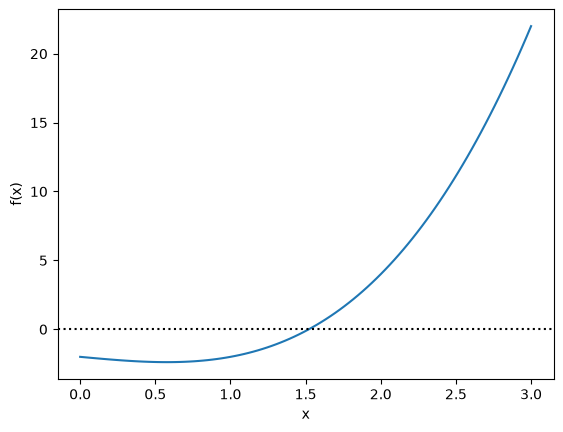

In [3]:
def f(x):
    return x**3 - x - 2

x_vec = np.linspace(0.0, 3.0, 100)
plt.plot(x_vec, f(x_vec))
plt.axhline(0.0, linestyle=':', color='black')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.show()

**Bisection.** Start from a bracket $[\underline{x},\overline{x}]$ where $f$ changes sign. Evaluate $f$ at the midpoint and keep the half where the sign still changes. The bracket halves at each iteration: slow, but it always converges when $f$ is continuous.

In [4]:
def bisection(f, x_low, x_high, tol=1e-8, max_iter=100):
    """ find a root of f in the bracket [x_low, x_high] """

    f_low = f(x_low)
    assert f_low*f(x_high) < 0

    for it in range(max_iter):

        # a. midpoint
        x_mid = (x_low+x_high)/2
        f_mid = f(x_mid)
        print(f'{it:3d}: x = {x_mid:.8f}, f(x) = {f_mid:10.2e}')

        # b. check convergence
        if abs(f_mid) < tol:
            return x_mid

        # c. keep the half where the sign changes
        if f_low*f_mid < 0:
            x_high = x_mid
        else:
            x_low, f_low = x_mid, f_mid

x_bisection = bisection(f, 0.0, 3.0)

  0: x = 1.50000000, f(x) =  -1.25e-01
  1: x = 2.25000000, f(x) =   7.14e+00
  2: x = 1.87500000, f(x) =   2.72e+00
  3: x = 1.68750000, f(x) =   1.12e+00
  4: x = 1.59375000, f(x) =   4.54e-01
  5: x = 1.54687500, f(x) =   1.55e-01
  6: x = 1.52343750, f(x) =   1.23e-02
  7: x = 1.51171875, f(x) =  -5.70e-02
  8: x = 1.51757812, f(x) =  -2.25e-02
  9: x = 1.52050781, f(x) =  -5.18e-03
 10: x = 1.52197266, f(x) =   3.53e-03
 11: x = 1.52124023, f(x) =  -8.29e-04
 12: x = 1.52160645, f(x) =   1.35e-03
 13: x = 1.52142334, f(x) =   2.59e-04
 14: x = 1.52133179, f(x) =  -2.85e-04
 15: x = 1.52137756, f(x) =  -1.27e-05
 16: x = 1.52140045, f(x) =   1.23e-04
 17: x = 1.52138901, f(x) =   5.53e-05
 18: x = 1.52138329, f(x) =   2.13e-05
 19: x = 1.52138042, f(x) =   4.27e-06
 20: x = 1.52137899, f(x) =  -4.24e-06
 21: x = 1.52137971, f(x) =   1.45e-08
 22: x = 1.52137935, f(x) =  -2.11e-06
 23: x = 1.52137953, f(x) =  -1.05e-06
 24: x = 1.52137962, f(x) =  -5.17e-07
 25: x = 1.52137966, f(x)

**Newton.** Linearize $f$ around the current guess $x_n$ and solve the linear equation:

$$ x_{n+1} = x_n - \frac{f(x_n)}{f'(x_n)} $$

When we have no analytical derivative, as will be the case with the household block, we use a finite difference, $f'(x)\approx\frac{f(x+h)-f(x)}{h}$, which costs one extra evaluation of $f$ per iteration.

In [5]:
def newton(f, x, tol=1e-8, max_iter=100, h=1e-6):
    """ find a root of f starting from the guess x """

    for it in range(max_iter):

        # a. check convergence
        f_x = f(x)
        print(f'{it:3d}: x = {x:.8f}, f(x) = {f_x:10.2e}')
        if abs(f_x) < tol:
            return x

        # b. newton step with a numerical derivative
        f_prime = (f(x+h)-f_x)/h
        x = x - f_x/f_prime

x_newton = newton(f, 3.0)

  0: x = 3.00000000, f(x) =   2.20e+01
  1: x = 2.15384645, f(x) =   5.84e+00
  2: x = 1.70189260, f(x) =   1.23e+00
  3: x = 1.54225112, f(x) =   1.26e-01
  4: x = 1.52170673, f(x) =   1.94e-03
  5: x = 1.52137979, f(x) =   4.89e-07
  6: x = 1.52137971, f(x) =   4.07e-13


Newton needs far fewer iterations, but it has no bracket: from a bad guess it can diverge or jump outside the domain of $f$. Its big advantage is that it generalizes to many dimensions, which is what we will use for the transition path.

At the end of this notebook we use `brentq` from `scipy`, which keeps a bracket like bisection but takes faster steps when it is safe to do so.

## <a id='toc1_2_'></a>[Obtain the policy function with EGM](#toc0_)

In [6]:
def solve_hh_backwards_one_step(z_trans, z_grid, a_grid, sigma, beta, r, w, vbeg_a):

    Nz, Na = vbeg_a.shape
    a = np.zeros((Nz, Na))
    c = np.zeros((Nz, Na))

    # a. solve step
    for i_z in range(Nz):

        ## i. get c(a',z)
        c_endo = (beta*vbeg_a[i_z])**(-1/sigma)

        # ii. compute a_endo = (c(a',z) + a' - z) / (1+r)
        a_endo = (c_endo + a_grid-w*z_grid[i_z]) / (1+r)

        # iii. interpolation to fixed grid
        a[i_z] = np.interp(a_grid, a_endo, a_grid) # we interpolate the function a'(a_endo) at the point a_grid, which gives us a'(a_grid)!
        a[i_z,:] = np.fmax(a[i_z,:],0.0) # enforce borrowing constraint
        c[i_z] = (1+r)*a_grid + w*z_grid[i_z] - a[i_z]

    # b. expectation step
    RHS = (1+r)*c**(-sigma)
    vbeg_a_new = z_trans @ RHS

    return c, a, vbeg_a_new


In [7]:
w = 0.723408276673697
r = 0.0117958248643717

In [8]:
def egm_ss(r, w, par, max_iter = 10_000, tol = 1e-8, verbose = False):
    """ solve the EGM for the steady state """

    # a. initialize
    y = w*par.z_grid
    c = r*par.a_grid[np.newaxis,:] + y[:,np.newaxis]
    Va = (1+r)*c**(-par.sigma)

    # b. iterate
    for it in range(max_iter):

        # i. solve backwards
        c, a, Va_new = solve_hh_backwards_one_step(par.z_trans, par.z_grid, par.a_grid, par.sigma, par.beta, r, w, Va)

        # ii. check convergence
        error = np.max(np.abs(Va - Va_new))
        if verbose:
            print(error)
        if error < tol:
            break

        Va = Va_new.copy()

    return c, a, Va_new

c, a, Va = egm_ss(r, w, par, verbose = True)


234258.44255210413
210684.64291104535
188139.72246493213
167114.67395429267
147773.01125720376
130182.95168180251
114339.35730800126
100183.26250482257
87618.86639724136
76527.6686160781
68838.43950446055
61947.900661126594
55626.48465962999
49837.34997171268
44549.64355592185
39735.63759373734
35368.75688454218
31422.4077554337
27869.454935754533
24824.12391831976
22360.40981618868
20095.02270825504
18018.865319555043
16123.033415734651
14398.40356102027
12835.435576887336
11471.178882069362
10332.128398654168
9284.997587974824
8326.20017582021
7451.805438910262
6657.4989826263045
5990.805885495123
5390.991785307997
4840.689034558018
4337.8743678297615
3889.849930924305
3506.11985082092
3153.045902448561
2829.5906214628194
2543.2050788553024
2292.782702713579
2062.3118846250727
1851.319256995659
1671.5829177592968
1505.694623966774
1353.301528511045
1222.6370987679402
1102.0260238537012
992.7327949225146
896.9963167832757
808.5209620123933
730.5231490129663
659.7077686065459
595.65306

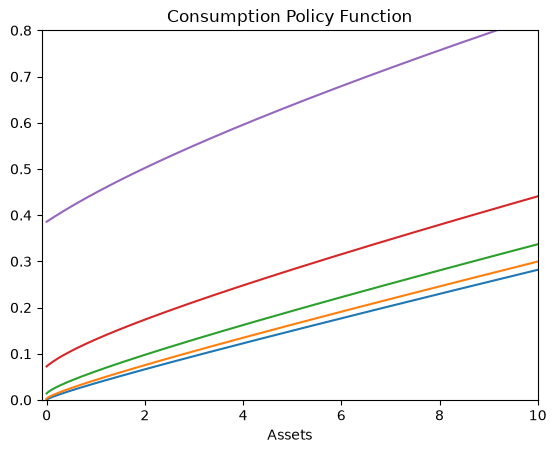

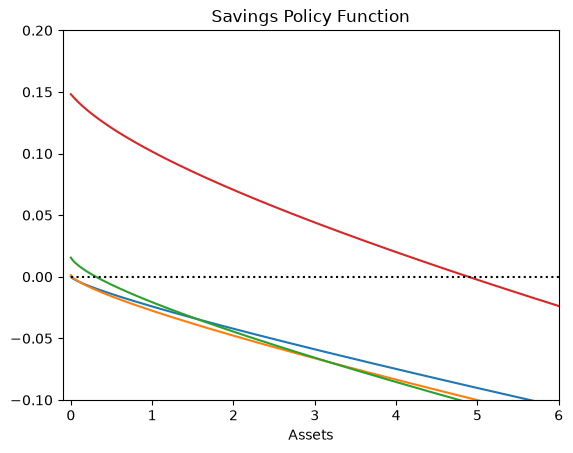

In [9]:
plt.plot(par.a_grid, c.T)
plt.xlim(-0.1, 10)
plt.ylim(0, 0.8)
plt.title('Consumption Policy Function')
plt.xlabel('Assets')
plt.show()

plt.plot(par.a_grid, (a-par.a_grid[np.newaxis,:]).T)
plt.plot(par.a_grid, np.zeros_like(par.a_grid), linestyle = ':', color = 'black')
plt.xlim(-0.1, 6)
plt.ylim(-0.1, 0.2)
plt.title('Savings Policy Function')
plt.xlabel('Assets')
plt.show()

## <a id='toc1_3_'></a>[Obtain the distribution using the histogram method](#toc0_)

In the consumption-saving lecture (`05_simulation.ipynb`) we saw how to go from the policy functions to the stationary distribution with the **histogram method** (Young, 2010):

1. Represent the distribution as masses on the grids: `Dbeg` is the beginning-of-period distribution over $(z_{t-1},a_{t-1})$, `D` the distribution over $(z_t,a_{t-1})$ after the productivity draw.
2. One period forward: apply the productivity transition, $D = \Pi_z' \cdot Dbeg$, then split each off-grid savings choice $a^{\ast}(z,a)$ between the two neighboring gridpoints with the lottery weight $\omega = \frac{a^{i+1}-a^{\ast}}{a^{i+1}-a^{i}}$.
3. This is a linear map: iterate it until the distribution is stationary.

Here we simply reuse that machinery.

In [10]:
def get_lottery(a, a_grid):
    """ lottery indices and weights for the savings policy """

    # a. i such that a_grid[i] <= a' <= a_grid[i+1]
    pol_indices = np.searchsorted(a_grid, a, side='right') - 1
    pol_indices = np.clip(pol_indices, 0, a_grid.size-2)

    # b. weight on the lower gridpoint
    pol_weights = (a_grid[pol_indices+1] - a)/(a_grid[pol_indices+1] - a_grid[pol_indices])

    return pol_indices, pol_weights

@nb.njit
def simulate_hh_forwards(z_trans, Dbeg, pol_indices, pol_weights):
    """ one period forward: productivity transition, then the savings lottery """

    # a. productivity transition
    D = z_trans.T@Dbeg

    # b. savings lottery
    Dbeg_plus = np.zeros_like(D)
    Nz, Na = D.shape
    for i_z in range(Nz):
        for i_a in range(Na):
            i = pol_indices[i_z,i_a]
            omega = pol_weights[i_z,i_a]
            Dbeg_plus[i_z,i] += omega*D[i_z,i_a]
            Dbeg_plus[i_z,i+1] += (1-omega)*D[i_z,i_a]

    return Dbeg_plus, D

In [11]:
def distribution_ss(a, par, tol=1e-10, max_iter=100_000):
    """ iterate the forward map until the distribution is stationary """

    pol_indices, pol_weights = get_lottery(a, par.a_grid)

    # a. initial guess: ergodic z, uniform assets
    Dbeg = par.z_ergodic[:,np.newaxis]*np.ones_like(par.a_grid)/par.Na

    # b. iterate
    for it in range(max_iter):
        Dbeg_plus, D = simulate_hh_forwards(par.z_trans, Dbeg, pol_indices, pol_weights)
        if np.max(np.abs(Dbeg_plus-Dbeg)) < tol:
            return D
        Dbeg = Dbeg_plus

D = distribution_ss(a, par)

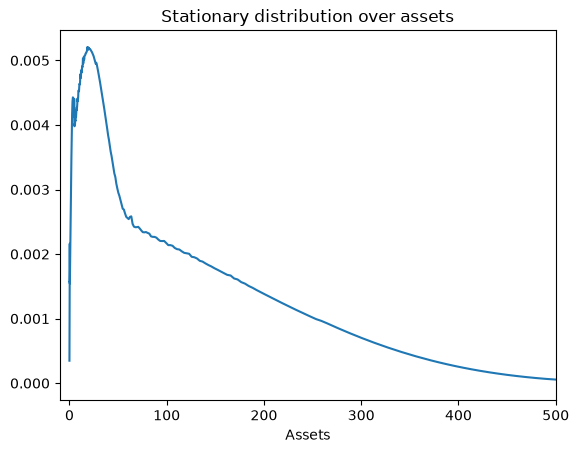

In [12]:
plt.plot(par.a_grid, np.sum(D, axis=0))
plt.xlim(-10, 500)
plt.title('Stationary distribution over assets')
plt.xlabel('Assets')
plt.show()

Two quick checks: the distribution sums to one, and there is no mass at the top of the grid (otherwise `a_max` is too small).

In [13]:
assert np.isclose(np.sum(D), 1)
assert np.isclose(np.sum(D[:,-1]), 0)

## <a id='toc1_4_'></a>[Obtain aggregate hh variables using policies and the distribution](#toc0_)

To compute aggregates, we integrate the policy functions over the distribution, which in our discrete world is just a sum. Note that we use `D`, the distribution *after* the productivity draw, because the policies are functions of $(z_t,a_{t-1})$.

Average productivity is one, so aggregate labor income is $w$. In the stationary equilibrium aggregate savings are constant, so the aggregate budget constraint gives us a check: $C = rA + w$.

In [14]:
A = np.sum(a*D)
C = np.sum(c*D)

print(f'A = {A:.4f}')
print(f'C = {C:.4f}')
print(f'r*A + w = {r*A + w:.4f}')

A = 31.6779
C = 1.0971
r*A + w = 1.0971


We have now seen how to:
1. Compute the policy functions of the households for a given $(r,w)$
2. Compute the associated stationary distribution
3. Compute the aggregate variables of the household block

We wrap these three steps into a single function:

In [15]:
def household_ss(r, w, par, max_iter = 10_000, tol = 1e-8, verbose = False):
    # 1. backward step: EGM
    c, a, Va = egm_ss(r, w, par, max_iter, tol, verbose)
    #. 2. forward step: distribution
    D = distribution_ss(a, par)
    # 3. aggregate
    A = np.sum(D * a)
    C = np.sum(D * c)
    return A, C, D, a, c, Va


## <a id='toc1_5_'></a>[Put everything together: solve for the steady-state in GE](#toc0_)

Now, let's move to solving the general equilibrium. The firm side pins down $r$ and $w$ as functions of $K$ (with $L=1$):

$$ r = \alpha \Gamma K^{\alpha-1} - \delta, \qquad w = (1-\alpha)\Gamma K^{\alpha} $$

In [16]:
def firm(K, Gamma, par):
    r = par.alpha * Gamma * K**(par.alpha-1) - par.delta
    Y = Gamma * K**par.alpha
    w = (1-par.alpha) * Y
    return r, w, Y

To see the equilibrium, we plot household asset supply $A(r)$ against capital demand $K(r)$: the stationary equilibrium is where the two curves cross. More patient households (higher $\beta$) supply more assets at every $r$, so the equilibrium interest rate falls.

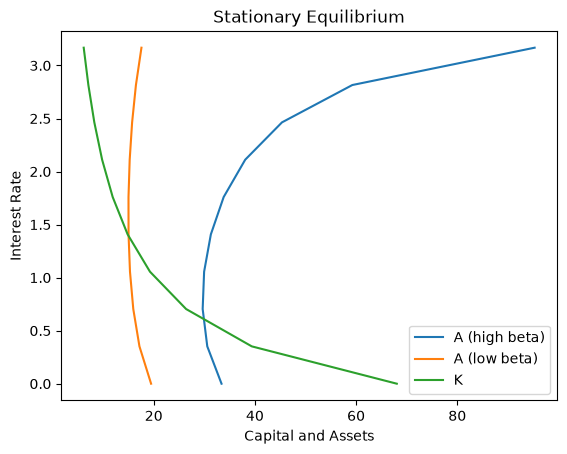

In [17]:
def asset_supply_r(r_vec, par):
    K_vec = ((r_vec+par.delta) / (par.alpha * par.Gamma))**(1/(par.alpha-1))
    w_vec = (1-par.alpha) * par.Gamma * K_vec**par.alpha
    A_vec = np.zeros(len(r_vec))
    for i in range(len(r_vec)):
        A_vec[i], _, _, _, _, _  = household_ss(r_vec[i], w_vec[i], par)
    return A_vec, K_vec

par_low_beta = Parameters()
par_low_beta.beta = par.beta * 0.98

Nr = 10
r_vec = np.linspace(0.0, (1/par.beta-1)*0.9, Nr)
A_vec, K_vec = asset_supply_r(r_vec, par)
A_vec_2, _ = asset_supply_r(r_vec, par_low_beta)
plt.plot(A_vec, r_vec * 100, label = 'A (high beta)')
plt.plot(A_vec_2, r_vec * 100, label = "A (low beta)")
plt.plot(K_vec, r_vec * 100, label = 'K')
plt.xlabel('Capital and Assets')
plt.ylabel('Interest Rate')
plt.title('Stationary Equilibrium')
plt.legend()

Finding the equilibrium is then a one-dimensional root-finding problem: find the $K$ such that the implied $(r,w)$ makes households want to hold exactly $A=K$. Asset supply explodes as $r$ approaches $1/\beta-1$, so a Newton step can easily land outside the domain. We therefore use a bracketing method (see the preamble), `brentq`.

In [18]:
def find_ss(K, par):
    r, w, Y = firm(K, par.Gamma, par)
    A, _, _, _, _, _  = household_ss(r, w, par)
    print(A-K)
    return A-K

K = brentq(find_ss, 5.0, 50.0, args=(par,))
print('Equilibrium K = ', K)
r, w, Y = firm(K, par.Gamma, par)
print('Equilibrium r = ', r*100)
print('Equilibrium w = ', w)

9994.99974127041
-18.384254731172305
-18.309884074740904
0.19837456736883397
-0.006690124859375146


-5.085179246577809e-06
-8.135714324453147e-13
-5.080380560684716e-13
8.668621376273222e-13
Equilibrium K =  29.824583120491624
Equilibrium r =  0.5864019120065376
Equilibrium w =  0.8269771812609502
